c:\Users\User\anaconda3\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


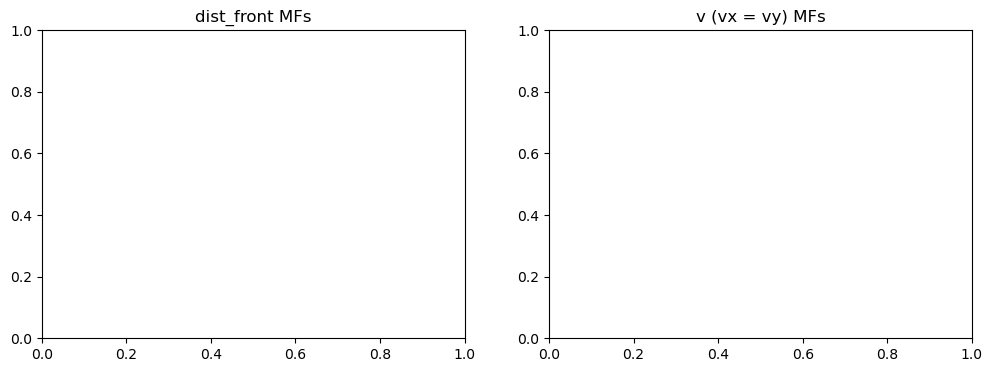

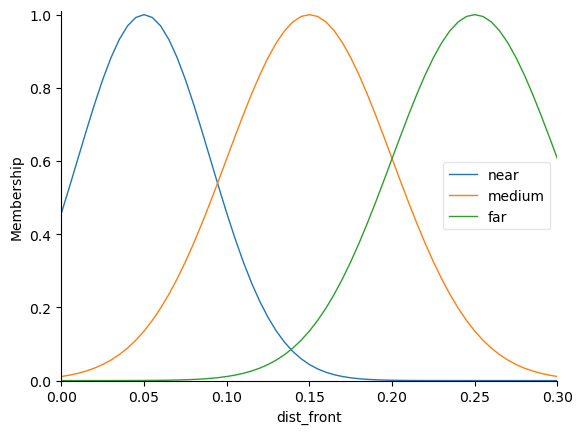

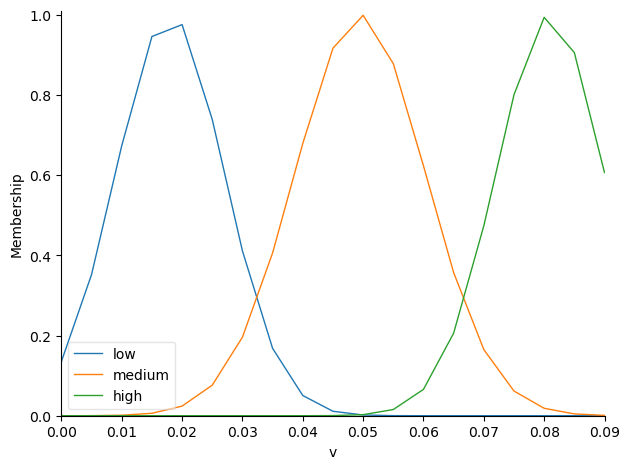

In [64]:
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Adiciona o diretório de serviços ao path
services_path = Path.cwd().parent / 'youbot' / 'services'
if str(services_path) not in sys.path:
    sys.path.insert(0, str(services_path))

from fuzzy_controller import FuzzySimple

# Instantiate controller
flc = FuzzySimple(v_max = 0.09)

# Plot MFs: entrada (dist_front) e saída (v)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
flc.dist_front.view(ax=axs[0])
axs[0].set_title('dist_front MFs')

# v é a saída única (vx = vy)
flc.v.view(ax=axs[1])
axs[1].set_title('v (vx = vy) MFs')

plt.tight_layout()
plt.show()

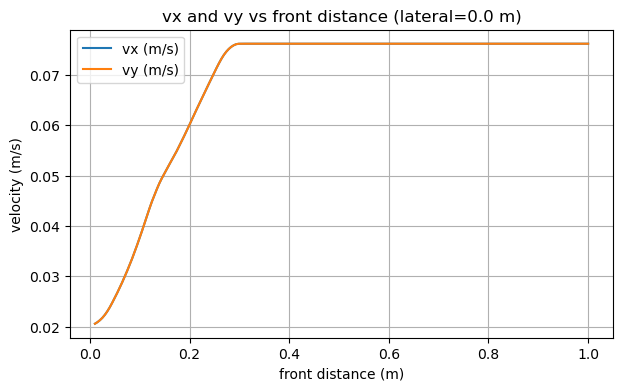

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# Instanciar o controlador simples ou o TSK original
flc = FuzzySimple(v_max = 0.09)   # ou FuzzySimple() se estiver usando a versão escalar

lateral = 0.0  # centered
p_vals = np.linspace(0.01, 1.0, 200)
vx_vals, vy_vals = [], []

for d in p_vals:
    vx, vy = flc.compute_velocity(d, lateral)
    vx_vals.append(vx)
    vy_vals.append(vy)

plt.figure(figsize=(7, 4))
plt.plot(p_vals, vx_vals, label='vx (m/s)')
plt.plot(p_vals, vy_vals, label='vy (m/s)')
plt.xlabel('front distance (m)')
plt.ylabel('velocity (m/s)')
plt.title('vx and vy vs front distance (lateral=0.0 m)')
plt.grid(True)
plt.legend()
plt.show()


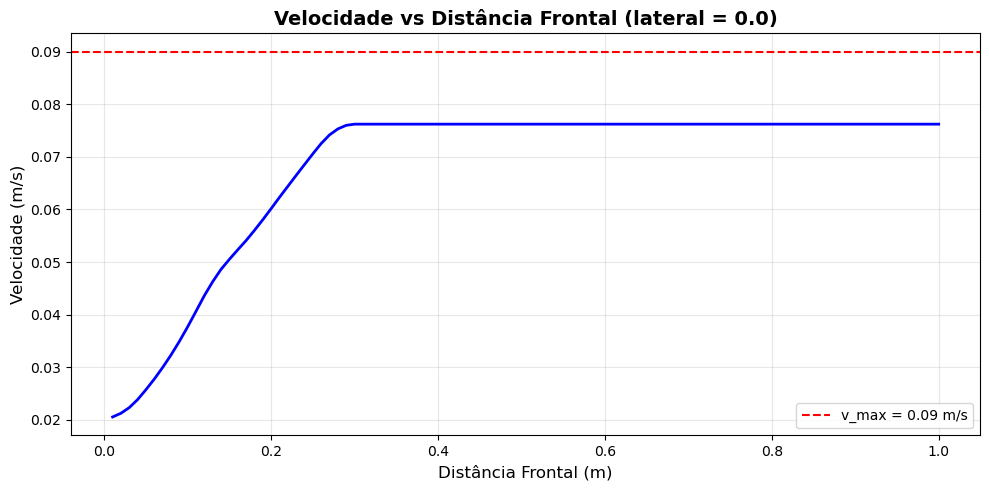


📊 EXEMPLOS DE ENTRADA → SAÍDA:
Distância: 0.05 m  →  Velocidade: 0.0257 m/s
Distância: 0.10 m  →  Velocidade: 0.0377 m/s
Distância: 0.15 m  →  Velocidade: 0.0505 m/s
Distância: 0.20 m  →  Velocidade: 0.0602 m/s
Distância: 0.30 m  →  Velocidade: 0.0762 m/s
Distância: 0.50 m  →  Velocidade: 0.0762 m/s
Distância: 0.80 m  →  Velocidade: 0.0762 m/s
Distância: 1.00 m  →  Velocidade: 0.0762 m/s


In [66]:
import numpy as np
import matplotlib.pyplot as plt
from fuzzy_controller import FuzzySimple

# Instantiate controller
flc = FuzzySimple(v_max=0.09)

# =====================================================
# 1️⃣ GRÁFICO: Distância → Velocidade (lateral = 0)
# =====================================================
distances = np.linspace(0.01, 1.0, 100)
lateral_offset = 0.0  # centralizado

velocities = []
for dist in distances:
    vx, vy = flc.compute_velocity(dist, lateral_offset)
    # vx e vy são iguais neste caso
    velocities.append(vx)

plt.figure(figsize=(10, 5))
plt.plot(distances, velocities, linewidth=2, color='blue')
plt.axhline(y=0.09, color='red', linestyle='--', label='v_max = 0.09 m/s')
plt.xlabel('Distância Frontal (m)', fontsize=12)
plt.ylabel('Velocidade (m/s)', fontsize=12)
plt.title('Velocidade vs Distância Frontal (lateral = 0.0)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 2️⃣ EXEMPLOS CONCRETOS (Tabela)
# =====================================================
print("\n📊 EXEMPLOS DE ENTRADA → SAÍDA:")
print("=" * 50)
test_distances = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 0.80, 1.00]

for dist in test_distances:
    vx, vy = flc.compute_velocity(dist, 0.0)
    print(f"Distância: {dist:.2f} m  →  Velocidade: {vx:.4f} m/s")

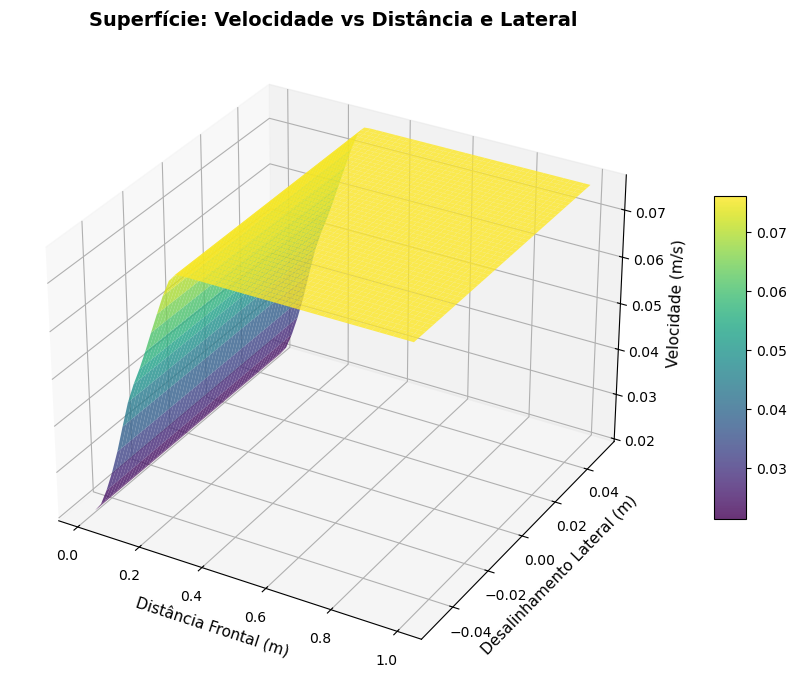

In [67]:
# =====================================================
# 3️⃣ SUPERFÍCIE 3D: Distância x Lateral → Velocidade
# =====================================================
from mpl_toolkits.mplot3d import Axes3D

distances = np.linspace(0.01, 1.0, 50)
laterals = np.linspace(-0.05, 0.05, 50)  # desalinhamento lateral

D, L = np.meshgrid(distances, laterals)
V = np.zeros_like(D)

for i in range(len(laterals)):
    for j in range(len(distances)):
        vx, vy = flc.compute_velocity(D[i, j], L[i, j])
        V[i, j] = vx  # ou np.hypot(vx, vy) para magnitude

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(D, L, V, cmap='viridis', alpha=0.8, edgecolor='none')
ax.set_xlabel('Distância Frontal (m)', fontsize=11)
ax.set_ylabel('Desalinhamento Lateral (m)', fontsize=11)
ax.set_zlabel('Velocidade (m/s)', fontsize=11)
ax.set_title('Superfície: Velocidade vs Distância e Lateral', fontsize=14, fontweight='bold')

fig.colorbar(surf, shrink=0.5, aspect=10)
plt.tight_layout()
plt.show()

Encontrados 111 arquivos de dados

Analisando: teste_1.csv

Ticks de alinhamento: 623
Ticks de aproximação: 159
Total: 782 ticks



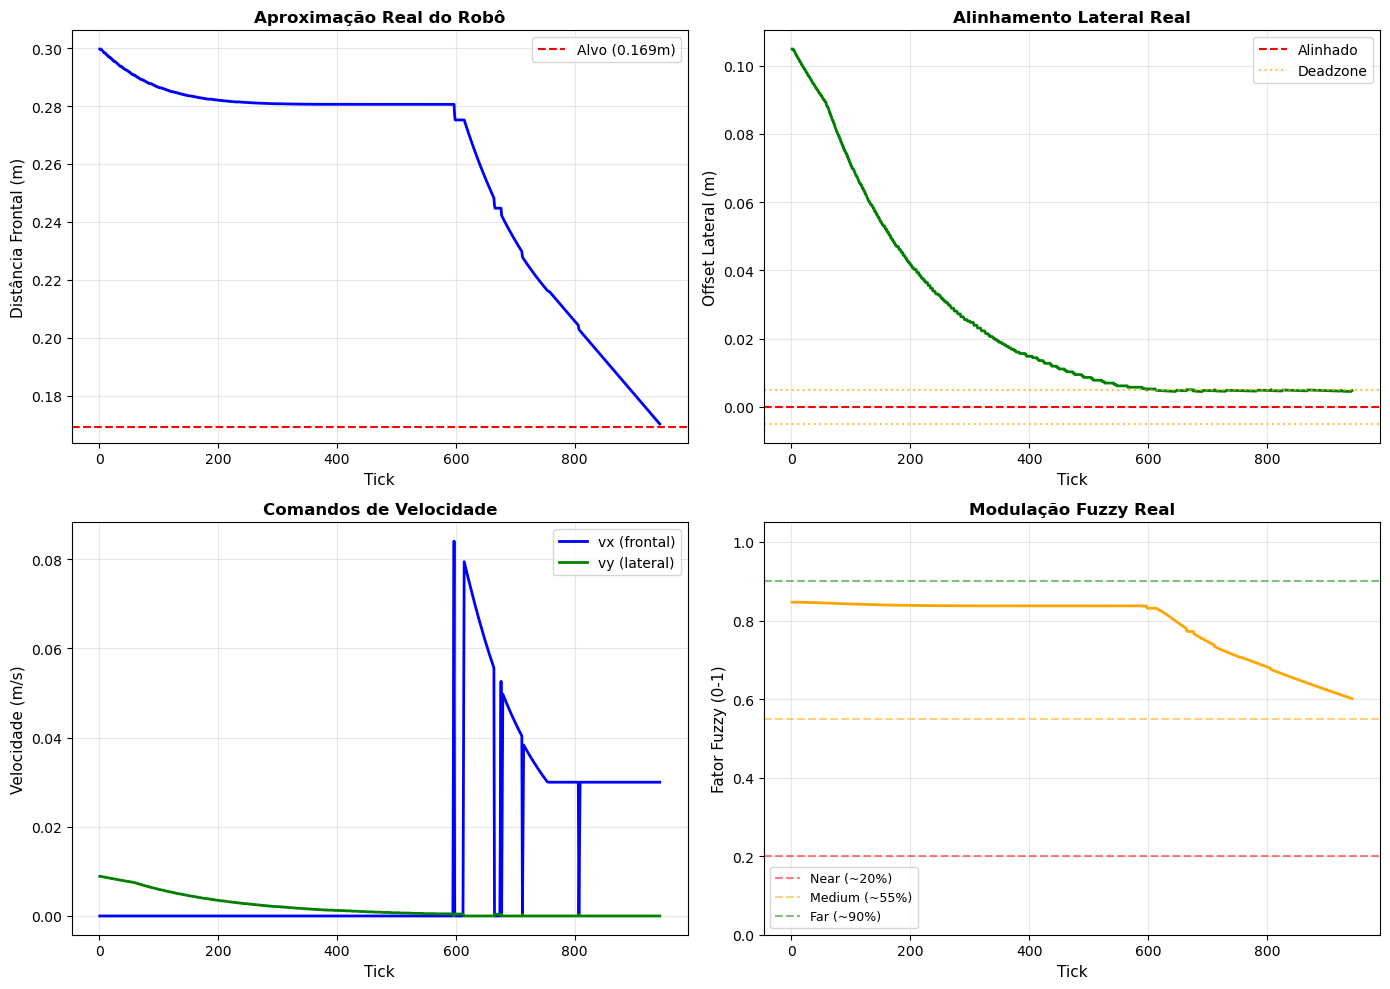

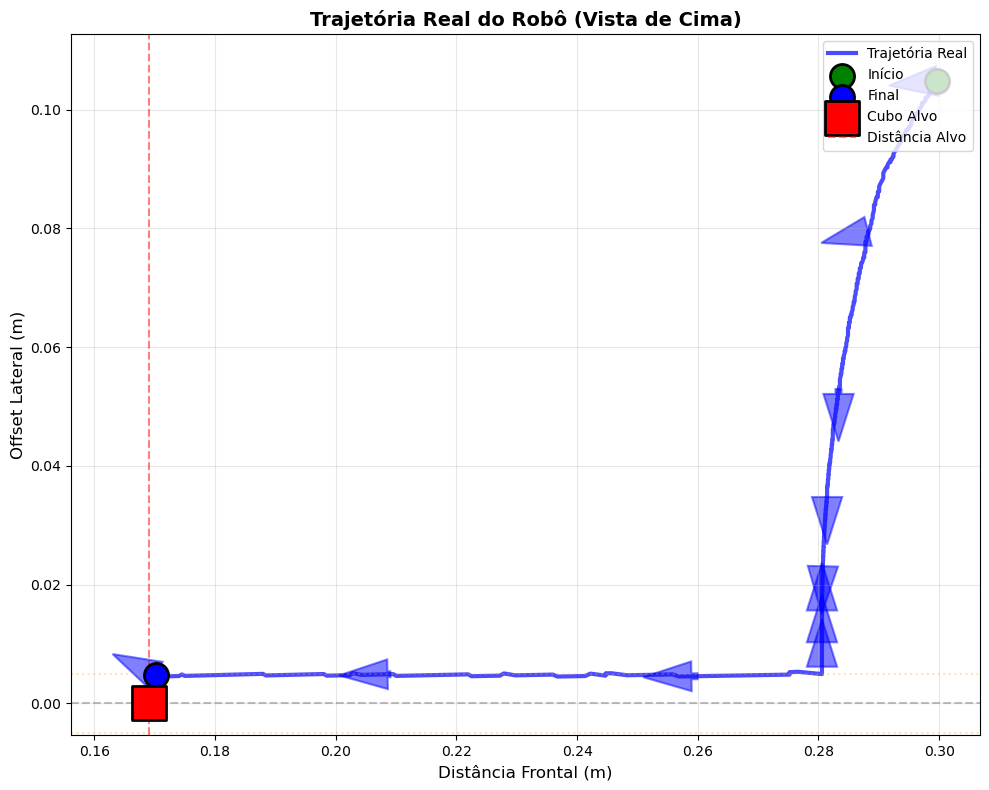


ESTATÍSTICAS DA SESSÃO:
Duração total: 782 ticks (~25.02s)

Distância inicial: 0.2997m
Distância final: 0.1702m
Erro final: 0.0012m

Offset lateral inicial: 0.1048m
Offset lateral final: 0.0048m

Fator fuzzy médio: 0.809
Fator fuzzy mínimo: 0.601
Fator fuzzy máximo: 0.847

Velocidade vx média: 0.0079 m/s
Velocidade vy média: 0.0023 m/s


In [68]:
# =====================================================
# 📊 ANÁLISE DE DADOS REAIS DE ALINHAMENTO
# =====================================================
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# Carregar dados
data_dir = Path(r"C:\Users\User\Documents\IA_PROJECT\Archives\Trabalho_IA_2025-fallback_begin_2\Trabalho_IA_2025-fallback_begin\controllers\youbot\fuzzy_alignment_data")
csv_files = sorted(data_dir.glob("alignment_*.csv"))

if not csv_files:
    print(" Nenhum arquivo de dados encontrado em 'fuzzy_alignment_data/'")
    print("Execute o robô primeiro para coletar dados!")
else:
    print(f"Encontrados {len(csv_files)} arquivos de dados\n")
    
    # Carregar o arquivo mais recente
    latest_file = csv_files[-1]
    data_file = Path(r"C:\Users\User\Documents\IA_PROJECT\Archives\Trabalho_IA_2025-fallback_begin_2\Trabalho_IA_2025-fallback_begin\controllers\youbot\fuzzy_alignment_data\teste_1.csv")

    print(f"Analisando: {data_file.name}\n")

    df = pd.read_csv(data_file)
    
    # Separar fases
    df_align = df[df['phase'] == 'align']
    df_approach = df[df['phase'] == 'approach']
    
    print(f"Ticks de alinhamento: {len(df_align)}")
    print(f"Ticks de aproximação: {len(df_approach)}")
    print(f"Total: {len(df)} ticks\n")
    
    # ===== GRÁFICOS =====
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Gráfico 1: Distância frontal
    ax1 = axes[0, 0]
    ax1.plot(df['tick'], df['dist_frontal'], 'b-', linewidth=2)
    ax1.axhline(y=0.169, color='r', linestyle='--', label='Alvo (0.169m)')
    ax1.set_xlabel('Tick', fontsize=11)
    ax1.set_ylabel('Distância Frontal (m)', fontsize=11)
    ax1.set_title('Aproximação Real do Robô', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Gráfico 2: Offset lateral
    ax2 = axes[0, 1]
    ax2.plot(df['tick'], df['offset_lateral'], 'g-', linewidth=2)
    ax2.axhline(y=0, color='r', linestyle='--', label='Alinhado')
    ax2.axhline(y=0.005, color='orange', linestyle=':', alpha=0.7, label='Deadzone')
    ax2.axhline(y=-0.005, color='orange', linestyle=':', alpha=0.7)
    ax2.set_xlabel('Tick', fontsize=11)
    ax2.set_ylabel('Offset Lateral (m)', fontsize=11)
    ax2.set_title('Alinhamento Lateral Real', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Gráfico 3: Velocidades
    ax3 = axes[1, 0]
    ax3.plot(df['tick'], df['vx'], 'b-', linewidth=2, label='vx (frontal)')
    ax3.plot(df['tick'], df['vy'], 'g-', linewidth=2, label='vy (lateral)')
    ax3.set_xlabel('Tick', fontsize=11)
    ax3.set_ylabel('Velocidade (m/s)', fontsize=11)
    ax3.set_title('Comandos de Velocidade', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # Gráfico 4: Fator fuzzy
    ax4 = axes[1, 1]
    ax4.plot(df['tick'], df['speed_factor'], 'orange', linewidth=2)
    ax4.set_xlabel('Tick', fontsize=11)
    ax4.set_ylabel('Fator Fuzzy (0-1)', fontsize=11)
    ax4.set_title('Modulação Fuzzy Real', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim([0, 1.05])
    ax4.axhline(y=0.2, color='red', linestyle='--', alpha=0.5, label='Near (~20%)')
    ax4.axhline(y=0.55, color='orange', linestyle='--', alpha=0.5, label='Medium (~55%)')
    ax4.axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='Far (~90%)')
    ax4.legend(fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # ===== TRAJETÓRIA 2D =====
    plt.figure(figsize=(10, 8))
    
    # Trajetória
    plt.plot(df['dist_frontal'], df['offset_lateral'], 'b-', linewidth=3, alpha=0.7, label='Trajetória Real')
    
    # Pontos de início e fim
    plt.scatter(df['dist_frontal'].iloc[0], df['offset_lateral'].iloc[0], 
                s=300, c='green', marker='o', label='Início', zorder=5, edgecolor='black', linewidth=2)
    plt.scatter(df['dist_frontal'].iloc[-1], df['offset_lateral'].iloc[-1], 
                s=300, c='blue', marker='o', label='Final', zorder=5, edgecolor='black', linewidth=2)
    
    # Cubo alvo
    plt.scatter([0.169], [0], s=600, c='red', marker='s', label='Cubo Alvo', zorder=5, edgecolor='black', linewidth=2)
    
    # Setas de direção
    step = max(1, len(df) // 10)
    for i in range(0, len(df)-1, step):
        dx = df['dist_frontal'].iloc[i+1] - df['dist_frontal'].iloc[i]
        dy = df['offset_lateral'].iloc[i+1] - df['offset_lateral'].iloc[i]
        plt.arrow(df['dist_frontal'].iloc[i], df['offset_lateral'].iloc[i], 
                  dx, dy, head_width=0.005, head_length=0.008, 
                  fc='blue', ec='blue', alpha=0.5, linewidth=1.5)
    
    plt.xlabel('Distância Frontal (m)', fontsize=12)
    plt.ylabel('Offset Lateral (m)', fontsize=12)
    plt.title('Trajetória Real do Robô (Vista de Cima)', fontsize=14, fontweight='bold')
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.axhline(y=0.005, color='orange', linestyle=':', alpha=0.3)
    plt.axhline(y=-0.005, color='orange', linestyle=':', alpha=0.3)
    plt.axvline(x=0.169, color='red', linestyle='--', alpha=0.5, label='Distância Alvo')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    # ===== ESTATÍSTICAS =====
    print("\nESTATÍSTICAS DA SESSÃO:")
    print("=" * 50)
    print(f"Duração total: {len(df)} ticks (~{len(df)*0.032:.2f}s)")
    print(f"\nDistância inicial: {df['dist_frontal'].iloc[0]:.4f}m")
    print(f"Distância final: {df['dist_frontal'].iloc[-1]:.4f}m")
    print(f"Erro final: {abs(df['dist_frontal'].iloc[-1] - 0.169):.4f}m")
    print(f"\nOffset lateral inicial: {df['offset_lateral'].iloc[0]:.4f}m")
    print(f"Offset lateral final: {df['offset_lateral'].iloc[-1]:.4f}m")
    print(f"\nFator fuzzy médio: {df['speed_factor'].mean():.3f}")
    print(f"Fator fuzzy mínimo: {df['speed_factor'].min():.3f}")
    print(f"Fator fuzzy máximo: {df['speed_factor'].max():.3f}")
    print(f"\nVelocidade vx média: {df['vx'].abs().mean():.4f} m/s")
    print(f"Velocidade vy média: {df['vy'].abs().mean():.4f} m/s")

📁 Encontrados 111 arquivos

ESTATÍSTICAS AGREGADAS DE TODAS AS SESSÕES

Total de sessões analisadas: 111

DURAÇÃO (ticks):
   Média: 835.2 ticks (~26.7s)
   Mediana: 856.0 ticks
   Min: 161 ticks
   Max: 1581 ticks
   Desvio padrão: 216.1 ticks

PRECISÃO DE DISTÂNCIA:
   Erro médio: 1.24 mm
   Erro mediano: 1.26 mm
   Melhor: 0.17 mm
   Pior: 1.48 mm

PRECISÃO LATERAL:
   Erro médio: 4.63 mm
   Erro mediano: 4.75 mm
   Melhor: 4.24 mm
   Pior: 5.22 mm

 FATOR FUZZY:
   Médio global: 0.737
   Range médio: 0.588 - 0.826

TAXA DE SUCESSO (<2cm erro): 111/111 (100.0%)


C:\Users\User\AppData\Local\Temp\ipykernel_36648\1935937732.py:109: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot([df_sessions['fuzzy_min'], df_sessions['fuzzy_medio'], df_sessions['fuzzy_max']],


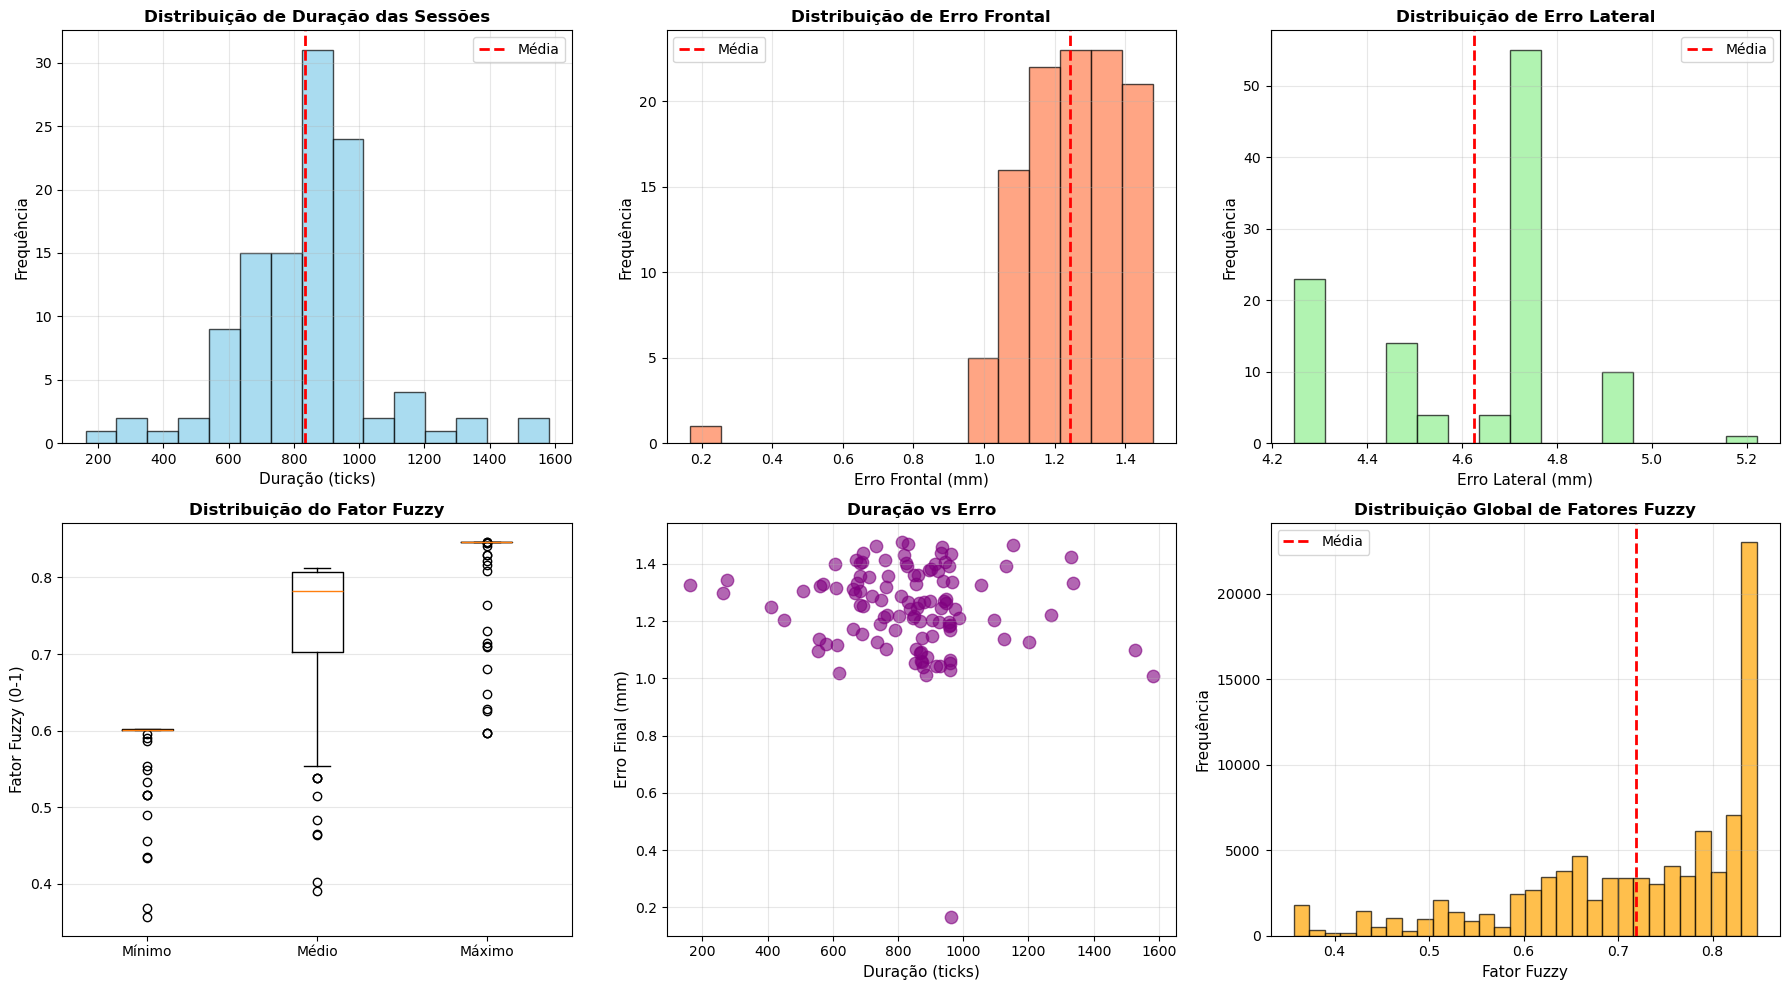

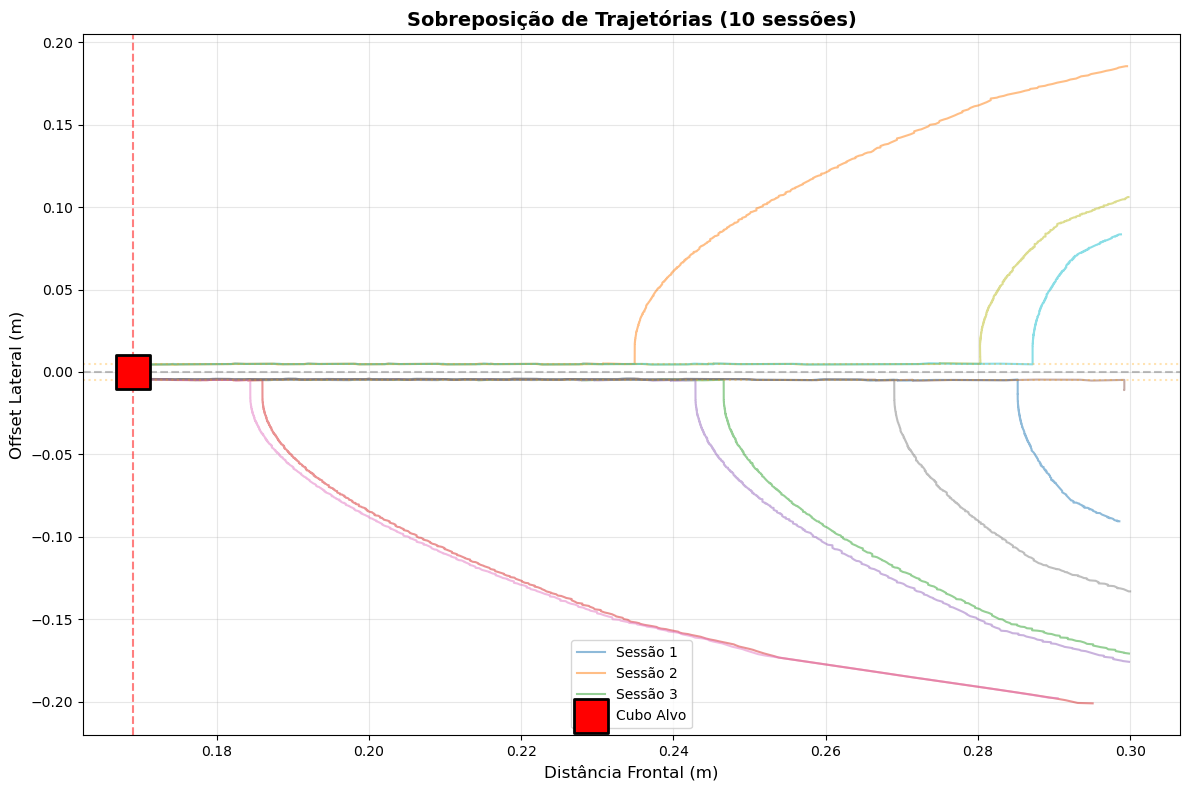

In [69]:

# Carregar TODOS os CSVs
data_dir = Path(r"C:\Users\User\Documents\IA_PROJECT\Archives\Trabalho_IA_2025-fallback_begin_2\Trabalho_IA_2025-fallback_begin\controllers\youbot\fuzzy_alignment_data")
csv_files = sorted(data_dir.glob("alignment_*.csv"))

if not csv_files:
    print("❌ Nenhum arquivo encontrado!")
else:
    print(f"📁 Encontrados {len(csv_files)} arquivos\n")
    
    # ===== COLETA DE MÉTRICAS =====
    sessions = []
    all_factors = []
    all_durations = []
    all_errors_dist = []
    all_errors_lat = []
    
    for file in csv_files:
        df = pd.read_csv(file)
        
        # Métricas por sessão
        session_data = {
            'file': file.name,
            'duration': len(df),
            'dist_inicial': df['dist_frontal'].iloc[0],
            'dist_final': df['dist_frontal'].iloc[-1],
            'erro_dist': abs(df['dist_frontal'].iloc[-1] - 0.169),
            'lat_inicial': df['offset_lateral'].iloc[0],
            'lat_final': abs(df['offset_lateral'].iloc[-1]),
            'fuzzy_medio': df['speed_factor'].mean(),
            'fuzzy_min': df['speed_factor'].min(),
            'fuzzy_max': df['speed_factor'].max()
        }
        sessions.append(session_data)
        
        # Acumula para distribuições
        all_factors.extend(df['speed_factor'].tolist())
        all_durations.append(len(df))
        all_errors_dist.append(session_data['erro_dist'])
        all_errors_lat.append(session_data['lat_final'])
    
    df_sessions = pd.DataFrame(sessions)
    
    # ===== ESTATÍSTICAS GERAIS =====
    print("=" * 60)
    print("ESTATÍSTICAS AGREGADAS DE TODAS AS SESSÕES")
    print("=" * 60)
    print(f"\nTotal de sessões analisadas: {len(sessions)}")
    print(f"\nDURAÇÃO (ticks):")
    print(f"   Média: {df_sessions['duration'].mean():.1f} ticks (~{df_sessions['duration'].mean()*0.032:.1f}s)")
    print(f"   Mediana: {df_sessions['duration'].median():.1f} ticks")
    print(f"   Min: {df_sessions['duration'].min()} ticks")
    print(f"   Max: {df_sessions['duration'].max()} ticks")
    print(f"   Desvio padrão: {df_sessions['duration'].std():.1f} ticks")
    
    print(f"\nPRECISÃO DE DISTÂNCIA:")
    print(f"   Erro médio: {df_sessions['erro_dist'].mean()*1000:.2f} mm")
    print(f"   Erro mediano: {df_sessions['erro_dist'].median()*1000:.2f} mm")
    print(f"   Melhor: {df_sessions['erro_dist'].min()*1000:.2f} mm")
    print(f"   Pior: {df_sessions['erro_dist'].max()*1000:.2f} mm")
    
    print(f"\nPRECISÃO LATERAL:")
    print(f"   Erro médio: {df_sessions['lat_final'].mean()*1000:.2f} mm")
    print(f"   Erro mediano: {df_sessions['lat_final'].median()*1000:.2f} mm")
    print(f"   Melhor: {df_sessions['lat_final'].min()*1000:.2f} mm")
    print(f"   Pior: {df_sessions['lat_final'].max()*1000:.2f} mm")
    
    print(f"\n FATOR FUZZY:")
    print(f"   Médio global: {df_sessions['fuzzy_medio'].mean():.3f}")
    print(f"   Range médio: {df_sessions['fuzzy_min'].mean():.3f} - {df_sessions['fuzzy_max'].mean():.3f}")
    
    sucesso = (df_sessions['erro_dist'] < 0.020).sum()  # < 2cm
    print(f"\nTAXA DE SUCESSO (<2cm erro): {sucesso}/{len(sessions)} ({100*sucesso/len(sessions):.1f}%)")
    
    # ===== GRÁFICOS AGREGADOS =====
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # 1. Histograma de duração
    ax1 = axes[0, 0]
    ax1.hist(all_durations, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
    ax1.axvline(df_sessions['duration'].mean(), color='red', linestyle='--', linewidth=2, label='Média')
    ax1.set_xlabel('Duração (ticks)', fontsize=11)
    ax1.set_ylabel('Frequência', fontsize=11)
    ax1.set_title('Distribuição de Duração das Sessões', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Histograma de erro de distância
    ax2 = axes[0, 1]
    ax2.hist([e*1000 for e in all_errors_dist], bins=15, color='coral', edgecolor='black', alpha=0.7)
    ax2.axvline(df_sessions['erro_dist'].mean()*1000, color='red', linestyle='--', linewidth=2, label='Média')
    ax2.set_xlabel('Erro Frontal (mm)', fontsize=11)
    ax2.set_ylabel('Frequência', fontsize=11)
    ax2.set_title('Distribuição de Erro Frontal', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Histograma de erro lateral
    ax3 = axes[0, 2]
    ax3.hist([e*1000 for e in all_errors_lat], bins=15, color='lightgreen', edgecolor='black', alpha=0.7)
    ax3.axvline(df_sessions['lat_final'].mean()*1000, color='red', linestyle='--', linewidth=2, label='Média')
    ax3.set_xlabel('Erro Lateral (mm)', fontsize=11)
    ax3.set_ylabel('Frequência', fontsize=11)
    ax3.set_title('Distribuição de Erro Lateral', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Box plot de fator fuzzy
    ax4 = axes[1, 0]
    ax4.boxplot([df_sessions['fuzzy_min'], df_sessions['fuzzy_medio'], df_sessions['fuzzy_max']], 
                labels=['Mínimo', 'Médio', 'Máximo'])
    ax4.set_ylabel('Fator Fuzzy (0-1)', fontsize=11)
    ax4.set_title('Distribuição do Fator Fuzzy', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    
    # 5. Scatter: duração vs erro
    ax5 = axes[1, 1]
    ax5.scatter(all_durations, [e*1000 for e in all_errors_dist], alpha=0.6, s=80, color='purple')
    ax5.set_xlabel('Duração (ticks)', fontsize=11)
    ax5.set_ylabel('Erro Final (mm)', fontsize=11)
    ax5.set_title('Duração vs Erro', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3)
    
    # 6. Histograma de fatores fuzzy (todos os ticks)
    ax6 = axes[1, 2]
    ax6.hist(all_factors, bins=30, color='orange', edgecolor='black', alpha=0.7)
    ax6.axvline(np.mean(all_factors), color='red', linestyle='--', linewidth=2, label='Média')
    ax6.set_xlabel('Fator Fuzzy', fontsize=11)
    ax6.set_ylabel('Frequência', fontsize=11)
    ax6.set_title('Distribuição Global de Fatores Fuzzy', fontsize=12, fontweight='bold')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ===== COMPARAÇÃO DE TRAJETÓRIAS =====
    plt.figure(figsize=(12, 8))
    
    for i, file in enumerate(csv_files[:10]):  # Limita a 10 para não poluir
        df = pd.read_csv(file)
        alpha = 0.5 if i < len(csv_files) - 1 else 1.0
        linewidth = 1.5 if i < len(csv_files) - 1 else 3
        label = f'Sessão {i+1}' if i < 3 else None
        plt.plot(df['dist_frontal'], df['offset_lateral'], 
                 alpha=alpha, linewidth=linewidth, label=label)
    
    # Cubo alvo
    plt.scatter([0.169], [0], s=600, c='red', marker='s', 
                label='Cubo Alvo', zorder=10, edgecolor='black', linewidth=2)
    
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.axhline(y=0.005, color='orange', linestyle=':', alpha=0.3)
    plt.axhline(y=-0.005, color='orange', linestyle=':', alpha=0.3)
    plt.axvline(x=0.169, color='red', linestyle='--', alpha=0.5)
    
    plt.xlabel('Distância Frontal (m)', fontsize=12)
    plt.ylabel('Offset Lateral (m)', fontsize=12)
    plt.title(f'Sobreposição de Trajetórias ({min(10, len(csv_files))} sessões)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    


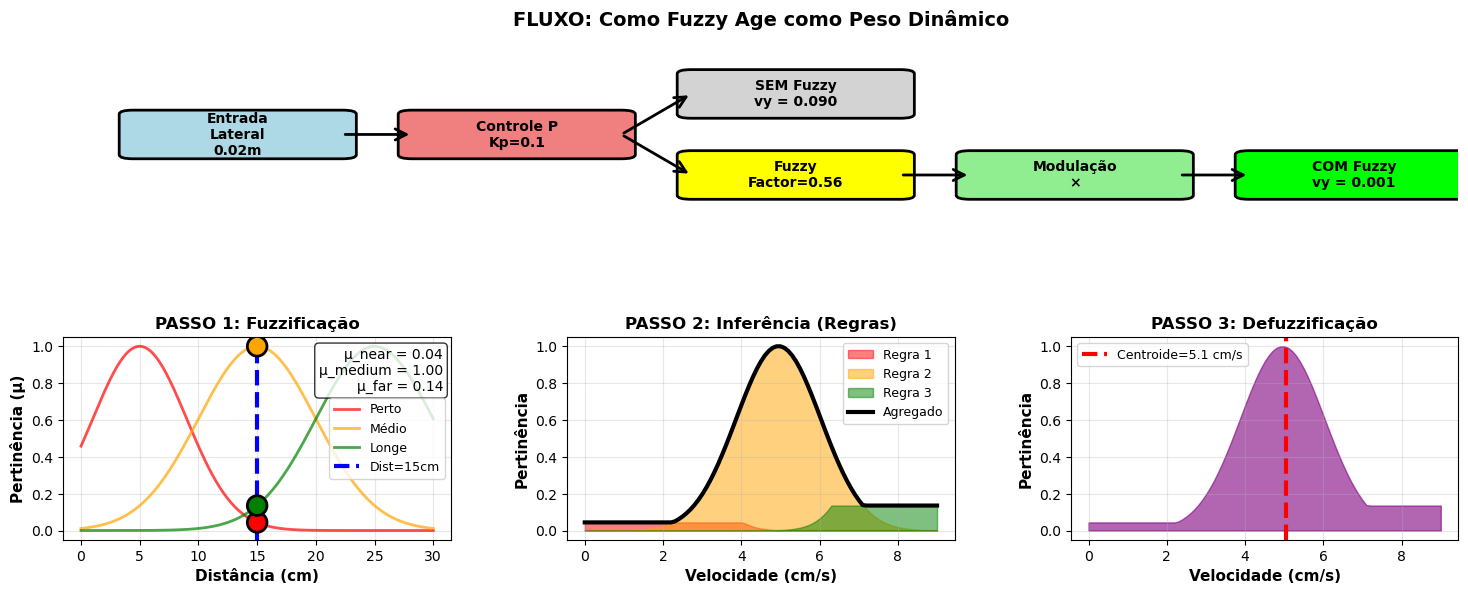

In [70]:
# ========================================
# CÉLULA: DEMONSTRAÇÃO COM PARÂMETROS REAIS DO YOUBOT

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import skfuzzy as fuzz

# ===== PARÂMETROS REAIS DO YOUBOT.PY =====
LIDAR_MAX = 0.3     
V_MAX = 0.09        
KP = 0.1           
MAX_VY = 0.09      
DEADZONE = 0.005    

# ===== EXEMPLO REALISTA: Distância = 15 cm, offset = 2 cm =====
exemplo_dist = 0.15   # metros
exemplo_lateral = 0.02  # metros

# ===== PASSO 1: CÁLCULO SEM FUZZY =====
speed_sem_fuzzy = KP * abs(exemplo_lateral)
vy_sem_fuzzy = min(speed_sem_fuzzy, MAX_VY)

# ===== PASSO 2: CÁLCULO DO FUZZY =====
# 2.1: Fuzzificação
dist_array = np.arange(0, LIDAR_MAX + 0.001, 0.001)
near = fuzz.gaussmf(dist_array, 0.05, 0.04)
medium = fuzz.gaussmf(dist_array, 0.15, 0.05)
far = fuzz.gaussmf(dist_array, 0.25, 0.05)

idx = np.argmin(np.abs(dist_array - exemplo_dist))
μ_near = near[idx]
μ_medium = medium[idx]
μ_far = far[idx]

# 2.2: Inferência
v_array = np.arange(0, V_MAX + 0.001, 0.001)
v_low = fuzz.gaussmf(v_array, 0.20 * V_MAX, 0.10 * V_MAX)
v_med = fuzz.gaussmf(v_array, 0.55 * V_MAX, 0.12 * V_MAX)
v_high = fuzz.gaussmf(v_array, 0.90 * V_MAX, 0.10 * V_MAX)

rule1 = np.fmin(μ_near, v_low)
rule2 = np.fmin(μ_medium, v_med)
rule3 = np.fmin(μ_far, v_high)
aggregated = np.fmax(rule1, np.fmax(rule2, rule3))

# 2.3: Defuzzificação
v_fuzzy = fuzz.defuzz(v_array, aggregated, 'centroid')

# 2.4: Normalização (PESO DINÂMICO)
speed_factor = v_fuzzy / V_MAX

# ===== PASSO 3: APLICAR PESO =====
speed_com_fuzzy = speed_sem_fuzzy * speed_factor
vy_com_fuzzy = min(speed_com_fuzzy, MAX_VY)

# ===== VISUALIZAÇÃO =====
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# [Resto do código de visualização igual ao anterior, mas com valores atualizados]

# ===== PLOT 1: Diagrama de Blocos =====
ax_diagram = fig.add_subplot(gs[0, :])
ax_diagram.set_xlim(0, 10)
ax_diagram.set_ylim(0, 5)
ax_diagram.axis('off')

# Blocos
boxes = [
    (0.5, 2.5, 1.5, 1, 'Entrada\nLateral\n0.02m', 'lightblue'),
    (2.5, 2.5, 1.5, 1, 'Controle P\nKp=0.1', 'lightcoral'),
    (4.5, 3.5, 1.5, 1, 'SEM Fuzzy\nvy = 0.090', 'lightgray'),
    (4.5, 1.5, 1.5, 1, f'Fuzzy\nFactor={speed_factor:.2f}', 'yellow'),
    (6.5, 1.5, 1.5, 1, 'Modulação\n×', 'lightgreen'),
    (8.5, 1.5, 1.5, 1, f'COM Fuzzy\nvy = {vy_com_fuzzy:.3f}', 'lime'),
]

for x, y, w, h, text, color in boxes:
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1", 
                         facecolor=color, edgecolor='black', linewidth=2)
    ax_diagram.add_patch(box)
    ax_diagram.text(x + w/2, y + h/2, text, ha='center', va='center', 
                   fontsize=10, fontweight='bold')

# Setas
arrows = [
    (2, 3, 2.5, 3, 'offset'),
    (4, 3, 4.5, 4, 'Kp × offset'),
    (4, 3, 4.5, 2, 'dist'),
    (6, 2, 6.5, 2, 'factor'),
    (8, 2, 8.5, 2, 'vy_final'),
]

for x1, y1, x2, y2, label in arrows:
    arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->', 
                           mutation_scale=20, linewidth=2, color='black')
    ax_diagram.add_patch(arrow)

ax_diagram.set_title('FLUXO: Como Fuzzy Age como Peso Dinâmico', 
                    fontsize=14, fontweight='bold', pad=20)

# ===== PLOT 2: Fuzzificação =====
ax_fuzz = fig.add_subplot(gs[1, 0])
ax_fuzz.plot(dist_array*100, near, 'r-', linewidth=2, label='Perto', alpha=0.7)
ax_fuzz.plot(dist_array*100, medium, 'orange', linewidth=2, label='Médio', alpha=0.7)
ax_fuzz.plot(dist_array*100, far, 'g-', linewidth=2, label='Longe', alpha=0.7)
ax_fuzz.axvline(exemplo_dist*100, color='blue', linestyle='--', linewidth=3, label=f'Dist={exemplo_dist*100:.0f}cm')
ax_fuzz.scatter([exemplo_dist*100]*3, [μ_near, μ_medium, μ_far], 
               s=200, c=['red', 'orange', 'green'], edgecolor='black', linewidth=2, zorder=5)
ax_fuzz.set_xlabel('Distância (cm)', fontsize=11, fontweight='bold')
ax_fuzz.set_ylabel('Pertinência (μ)', fontsize=11, fontweight='bold')
ax_fuzz.set_title('PASSO 1: Fuzzificação', fontsize=12, fontweight='bold')
ax_fuzz.legend(fontsize=9)
ax_fuzz.grid(True, alpha=0.3)

# Anotação
textstr = f'μ_near = {μ_near:.2f}\nμ_medium = {μ_medium:.2f}\nμ_far = {μ_far:.2f}'
ax_fuzz.text(0.98, 0.95, textstr, transform=ax_fuzz.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ===== PLOT 3: Inferência =====
ax_infer = fig.add_subplot(gs[1, 1])
ax_infer.fill_between(v_array*100, 0, rule1, alpha=0.5, color='red', label='Regra 1')
ax_infer.fill_between(v_array*100, 0, rule2, alpha=0.5, color='orange', label='Regra 2')
ax_infer.fill_between(v_array*100, 0, rule3, alpha=0.5, color='green', label='Regra 3')
ax_infer.plot(v_array*100, aggregated, 'k-', linewidth=3, label='Agregado')
ax_infer.set_xlabel('Velocidade (cm/s)', fontsize=11, fontweight='bold')
ax_infer.set_ylabel('Pertinência', fontsize=11, fontweight='bold')
ax_infer.set_title('PASSO 2: Inferência (Regras)', fontsize=12, fontweight='bold')
ax_infer.legend(fontsize=9)
ax_infer.grid(True, alpha=0.3)

# ===== PLOT 4: Defuzzificação =====
ax_defuzz = fig.add_subplot(gs[1, 2])
ax_defuzz.fill_between(v_array*100, 0, aggregated, alpha=0.6, color='purple')
ax_defuzz.axvline(v_fuzzy*100, color='red', linestyle='--', linewidth=3, 
                 label=f'Centroide={v_fuzzy*100:.1f} cm/s')
ax_defuzz.set_xlabel('Velocidade (cm/s)', fontsize=11, fontweight='bold')
ax_defuzz.set_ylabel('Pertinência', fontsize=11, fontweight='bold')
ax_defuzz.set_title('PASSO 3: Defuzzificação', fontsize=12, fontweight='bold')
ax_defuzz.legend(fontsize=9)
ax_defuzz.grid(True, alpha=0.3)


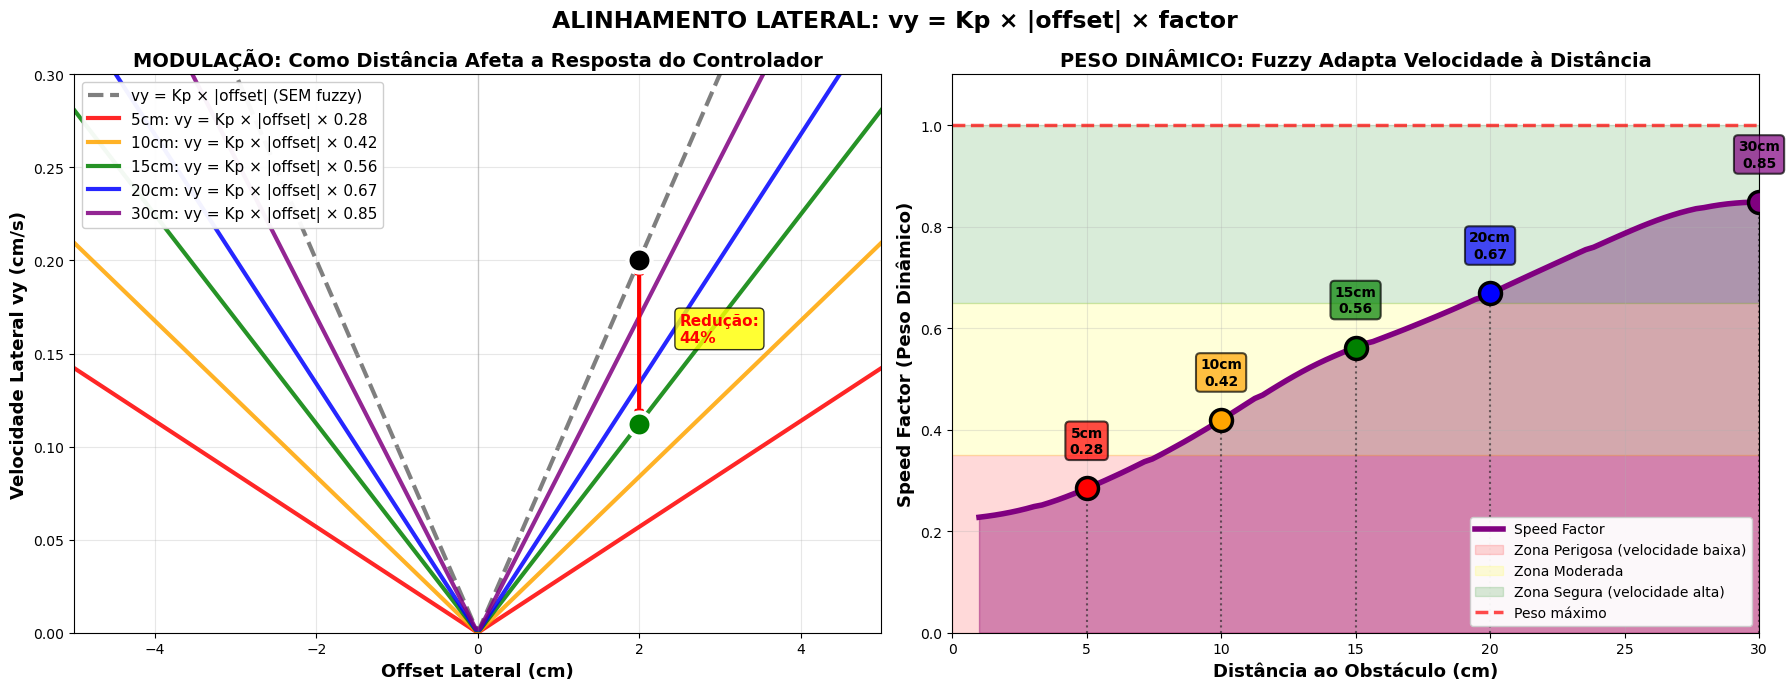


 ANÁLISE: FUNÇÃO DE ALINHAMENTO COM FUZZY

FÓRMULA: vy = Kp × |offset| × speed_factor
Kp = 0.1, MAX_VY = 0.09 m/s

EXEMPLO: offset lateral = 2 cm (robô desalinhado)
--------------------------------------------------------------------------------
Distância       Fator        vy SEM          vy COM          Redução
--------------------------------------------------------------------------------
     5 cm        0.284         0.20 cm/s       0.06 cm/s     71.6%
    10 cm        0.419         0.20 cm/s       0.08 cm/s     58.1%
    15 cm        0.562         0.20 cm/s       0.11 cm/s     43.8%
    20 cm        0.669         0.20 cm/s       0.13 cm/s     33.1%
    30 cm        0.848         0.20 cm/s       0.17 cm/s     15.2%

INTERPRETAÇÃO:
  ✅ Perto (5cm):  Fuzzy reduz velocidade em ~72% → segurança máxima
  ⚠️  Médio (15cm): Fuzzy reduz velocidade em ~44% → equilíbrio
  ✅ Longe (30cm): Fuzzy mantém ~85% da velocidade → eficiência


In [71]:
# ========================================
# FUNÇÃO DE ALINHAMENTO: VERSÃO OTIMIZADA PARA APRESENTAÇÃO
# ========================================

# ===== CALCULAR FUZZY =====
dist_array = np.arange(0, LIDAR_MAX + 0.001, 0.001)
near = fuzz.gaussmf(dist_array, 0.05, 0.04)
medium = fuzz.gaussmf(dist_array, 0.15, 0.05)
far = fuzz.gaussmf(dist_array, 0.25, 0.05)

v_array = np.arange(0, V_MAX + 0.001, 0.001)
v_low = fuzz.gaussmf(v_array, 0.20 * V_MAX, 0.10 * V_MAX)
v_med = fuzz.gaussmf(v_array, 0.55 * V_MAX, 0.12 * V_MAX)
v_high = fuzz.gaussmf(v_array, 0.90 * V_MAX, 0.10 * V_MAX)

def calcular_speed_factor(dist):
    idx = np.argmin(np.abs(dist_array - dist))
    μ_near = near[idx]
    μ_medium = medium[idx]
    μ_far = far[idx]
    
    rule1 = np.fmin(μ_near, v_low)
    rule2 = np.fmin(μ_medium, v_med)
    rule3 = np.fmin(μ_far, v_high)
    aggregated = np.fmax(rule1, np.fmax(rule2, rule3))
    
    v_fuzzy = fuzz.defuzz(v_array, aggregated, 'centroid')
    return v_fuzzy / V_MAX

# ===== VISUALIZAÇÃO OTIMIZADA (2 GRÁFICOS PRINCIPAIS) =====
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ===== GRÁFICO 1: COMPARAÇÃO DIRETA (BEM MAIOR) =====
ax1 = axes[0]
offsets = np.linspace(-0.05, 0.05, 200)
distancias_teste = [0.05, 0.10, 0.15, 0.20, 0.30]
colors = ['red', 'orange', 'green', 'blue', 'purple']

# Linha SEM fuzzy (referência)
vy_sem = np.array([min(KP * abs(offset), MAX_VY) for offset in offsets])
ax1.plot(offsets*100, vy_sem*100, 'k--', linewidth=3, label='vy = Kp × |offset| (SEM fuzzy)', alpha=0.5, zorder=1)

# Linhas COM fuzzy (diferentes distâncias)
for dist, color in zip(distancias_teste, colors):
    factor = calcular_speed_factor(dist)
    vy_com = np.array([min(KP * abs(offset) * factor, MAX_VY) for offset in offsets])
    ax1.plot(offsets*100, vy_com*100, linewidth=3, color=color, 
             label=f'{dist*100:.0f}cm: vy = Kp × |offset| × {factor:.2f}', alpha=0.85)

# Destacar exemplo específico (15cm, 2cm offset)
dist_destaque = 0.15
offset_destaque = 0.02
factor_destaque = calcular_speed_factor(dist_destaque)
vy_sem_dest = min(KP * abs(offset_destaque), MAX_VY)
vy_com_dest = min(KP * abs(offset_destaque) * factor_destaque, MAX_VY)

ax1.scatter([offset_destaque*100], [vy_sem_dest*100], s=300, c='black', marker='o', 
           edgecolor='white', linewidth=3, zorder=10, label='_nolegend_')
ax1.scatter([offset_destaque*100], [vy_com_dest*100], s=300, c='green', marker='o', 
           edgecolor='white', linewidth=3, zorder=10, label='_nolegend_')

# Seta mostrando redução
ax1.annotate('', xy=(offset_destaque*100, vy_com_dest*100), 
            xytext=(offset_destaque*100, vy_sem_dest*100),
            arrowprops=dict(arrowstyle='<->', lw=3, color='red'))
ax1.text(offset_destaque*100 + 0.5, (vy_sem_dest + vy_com_dest)*50, 
        f'Redução:\n{(1-factor_destaque)*100:.0f}%', 
        fontsize=11, fontweight='bold', color='red',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

ax1.axhline(MAX_VY*100, color='red', linestyle=':', linewidth=2, alpha=0.3)
ax1.axvline(0, color='gray', linestyle='-', linewidth=1, alpha=0.3)
ax1.set_xlabel('Offset Lateral (cm)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Velocidade Lateral vy (cm/s)', fontsize=13, fontweight='bold')
ax1.set_title('MODULAÇÃO: Como Distância Afeta a Resposta do Controlador', 
             fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax1.set_xlim([-5, 5])
ax1.set_ylim([0, 0.3])  # Zoom para mostrar detalhes

# ===== GRÁFICO 2: PESO DINÂMICO (VISUAL ATRATIVO) =====
ax2 = axes[1]
dists_plot = np.linspace(0.01, 0.30, 100)
factors = [calcular_speed_factor(d) for d in dists_plot]

# Curva principal
ax2.plot(dists_plot*100, factors, 'purple', linewidth=4, label='Speed Factor')
ax2.fill_between(dists_plot*100, 0, factors, alpha=0.4, color='purple')

# Marcar pontos de teste com anotações visuais
for dist, color in zip(distancias_teste, colors):
    factor = calcular_speed_factor(dist)
    ax2.scatter([dist*100], [factor], s=250, c=color, edgecolor='black', 
               linewidth=2.5, zorder=5)
    
    # Linha vertical pontilhada
    ax2.plot([dist*100, dist*100], [0, factor], 'k:', linewidth=1.5, alpha=0.5)
    
    # Label acima do ponto
    ax2.text(dist*100, factor + 0.07, f'{dist*100:.0f}cm\n{factor:.2f}', 
            ha='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor=color, alpha=0.7, edgecolor='black', linewidth=1.5))

# Zonas coloridas
ax2.axhspan(0, 0.35, alpha=0.15, color='red', label='Zona Perigosa (velocidade baixa)')
ax2.axhspan(0.35, 0.65, alpha=0.15, color='yellow', label='Zona Moderada')
ax2.axhspan(0.65, 1.0, alpha=0.15, color='green', label='Zona Segura (velocidade alta)')

ax2.axhline(1.0, color='red', linestyle='--', linewidth=2.5, alpha=0.7, label='Peso máximo')
ax2.set_xlabel('Distância ao Obstáculo (cm)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Speed Factor (Peso Dinâmico)', fontsize=13, fontweight='bold')
ax2.set_title('PESO DINÂMICO: Fuzzy Adapta Velocidade à Distância', 
             fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10, loc='lower right', framealpha=0.95)
ax2.set_ylim([0, 1.1])
ax2.set_xlim([0, 30])

plt.suptitle('ALINHAMENTO LATERAL: vy = Kp × |offset| × factor', 
            fontsize=17, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ===== TABELA RESUMO =====
print("\n" + "="*80)
print(" ANÁLISE: FUNÇÃO DE ALINHAMENTO COM FUZZY")
print("="*80)
print(f"\nFÓRMULA: vy = Kp × |offset| × speed_factor")
print(f"Kp = {KP}, MAX_VY = {MAX_VY} m/s")
print(f"\nEXEMPLO: offset lateral = 2 cm (robô desalinhado)")
print("-"*80)
print(f"{'Distância':<15} {'Fator':<12} {'vy SEM':<15} {'vy COM':<15} {'Redução'}")
print("-"*80)

for dist in distancias_teste:
    factor = calcular_speed_factor(dist)
    vy_sem = KP * 0.02 * 100  # em cm/s
    vy_com = KP * 0.02 * factor * 100
    reducao = (1 - factor) * 100
    
    print(f"{dist*100:>6.0f} cm       {factor:>6.3f}      {vy_sem:>7.2f} cm/s    {vy_com:>7.2f} cm/s    {reducao:>5.1f}%")

print("="*80)
print("\nINTERPRETAÇÃO:")
print("  ✅ Perto (5cm):  Fuzzy reduz velocidade em ~72% → segurança máxima")
print("  ⚠️  Médio (15cm): Fuzzy reduz velocidade em ~44% → equilíbrio")
print("  ✅ Longe (30cm): Fuzzy mantém ~85% da velocidade → eficiência")
print("="*80)

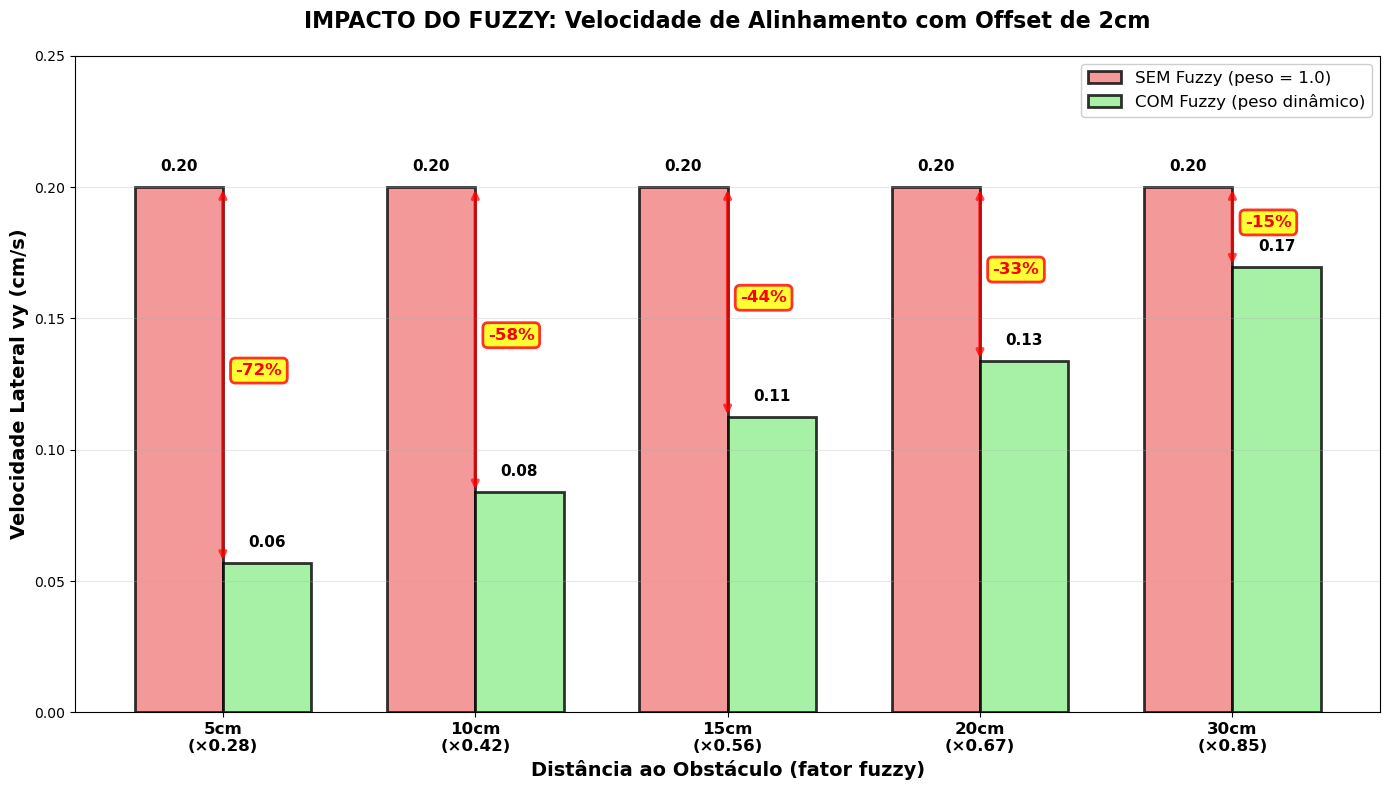

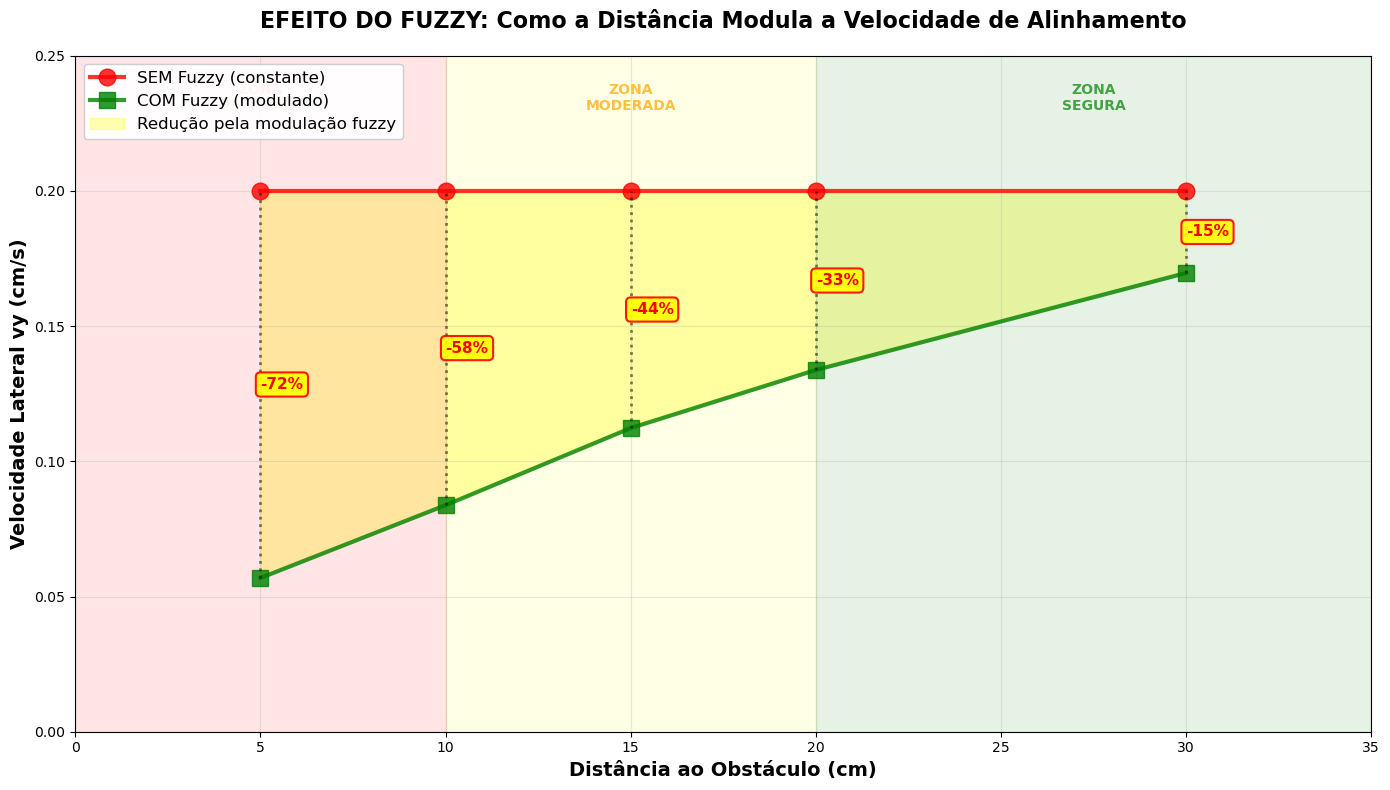

In [72]:
# ========================================
# GRÁFICO: IMPACTO DO FUZZY NA VELOCIDADE DE ALINHAMENTO
# ========================================

distancias_teste = [0.05, 0.10, 0.15, 0.20, 0.30]
offset_exemplo = 0.02 

# Calcular dados
dados = []
for dist in distancias_teste:
    factor = calcular_speed_factor(dist)
    vy_sem = KP * offset_exemplo * 100  # cm/s
    vy_com = KP * offset_exemplo * factor * 100  # cm/s
    reducao = (1 - factor) * 100
    dados.append({
        'dist': dist * 100,
        'factor': factor,
        'vy_sem': vy_sem,
        'vy_com': vy_com,
        'reducao': reducao
    })

# ===== GRÁFICO DE BARRAS COMPARATIVO =====
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

x_pos = np.arange(len(dados))
width = 0.35

# Barras SEM fuzzy
bars_sem = ax.bar(x_pos - width/2, [d['vy_sem'] for d in dados], width, 
                   label='SEM Fuzzy (peso = 1.0)', color='lightcoral', 
                   edgecolor='black', linewidth=2, alpha=0.8)

# Barras COM fuzzy
bars_com = ax.bar(x_pos + width/2, [d['vy_com'] for d in dados], width, 
                   label='COM Fuzzy (peso dinâmico)', color='lightgreen', 
                   edgecolor='black', linewidth=2, alpha=0.8)

# Adicionar valores nas barras
for i, (bar_sem, bar_com, d) in enumerate(zip(bars_sem, bars_com, dados)):
    # Valor SEM fuzzy
    ax.text(bar_sem.get_x() + bar_sem.get_width()/2, bar_sem.get_height() + 0.005,
            f'{d["vy_sem"]:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Valor COM fuzzy
    ax.text(bar_com.get_x() + bar_com.get_width()/2, bar_com.get_height() + 0.005,
            f'{d["vy_com"]:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Seta mostrando redução
    mid_x = x_pos[i]
    y_start = d['vy_sem']
    y_end = d['vy_com']
    
    ax.annotate('', xy=(mid_x, y_end), xytext=(mid_x, y_start),
                arrowprops=dict(arrowstyle='<->', lw=2.5, color='red', alpha=0.7))
    
    # Percentual de redução
    ax.text(mid_x + 0.05, (y_start + y_end)/2, f'-{d["reducao"]:.0f}%', 
            fontsize=12, fontweight='bold', color='red',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8, edgecolor='red', linewidth=2))

# Labels das distâncias
labels = [f'{d["dist"]:.0f}cm\n(×{d["factor"]:.2f})' for d in dados]
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=12, fontweight='bold')

# Configurações
ax.set_xlabel('Distância ao Obstáculo (fator fuzzy)', fontsize=14, fontweight='bold')
ax.set_ylabel('Velocidade Lateral vy (cm/s)', fontsize=14, fontweight='bold')
ax.set_title('IMPACTO DO FUZZY: Velocidade de Alinhamento com Offset de 2cm', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper right', framealpha=0.95)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 0.25])

plt.tight_layout()
plt.show()

# ===== GRÁFICO ALTERNATIVO: LINHAS COM ÁREA =====
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

dists = [d['dist'] for d in dados]
vy_sem_list = [d['vy_sem'] for d in dados]
vy_com_list = [d['vy_com'] for d in dados]

# Linhas principais
ax.plot(dists, vy_sem_list, 'o-', linewidth=3, markersize=12, color='red', 
        label='SEM Fuzzy (constante)', alpha=0.8)
ax.plot(dists, vy_com_list, 's-', linewidth=3, markersize=12, color='green', 
        label='COM Fuzzy (modulado)', alpha=0.8)

# Área de redução
ax.fill_between(dists, vy_com_list, vy_sem_list, alpha=0.3, color='yellow', 
                label='Redução pela modulação fuzzy')

# Anotações com percentuais
for i, d in enumerate(dados):
    # Linha vertical pontilhada
    ax.plot([d['dist'], d['dist']], [d['vy_com'], d['vy_sem']], 
            'k:', linewidth=2, alpha=0.5)
    
    # Percentual
    mid_y = (d['vy_sem'] + d['vy_com']) / 2
    ax.text(d['dist'], mid_y, f"-{d['reducao']:.0f}%", 
            fontsize=11, fontweight='bold', color='red',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.9, 
                     edgecolor='red', linewidth=1.5),
            ha='left', va='center')

# Configurações
ax.set_xlabel('Distância ao Obstáculo (cm)', fontsize=14, fontweight='bold')
ax.set_ylabel('Velocidade Lateral vy (cm/s)', fontsize=14, fontweight='bold')
ax.set_title('EFEITO DO FUZZY: Como a Distância Modula a Velocidade de Alinhamento', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 35])
ax.set_ylim([0, 0.25])

# Zonas de risco
ax.axvspan(0, 10, alpha=0.1, color='red', label='_nolegend_')
ax.axvspan(10, 20, alpha=0.1, color='yellow', label='_nolegend_')
ax.axvspan(20, 35, alpha=0.1, color='green', label='_nolegend_')

ax.text(5, 0.23, 'ZONA\nPERIGOSA', ha='center', fontsize=10, fontweight='bold', 
        color='red', alpha=0.7)
ax.text(15, 0.23, 'ZONA\nMODERADA', ha='center', fontsize=10, fontweight='bold', 
        color='orange', alpha=0.7)
ax.text(27.5, 0.23, 'ZONA\nSEGURA', ha='center', fontsize=10, fontweight='bold', 
        color='green', alpha=0.7)

plt.tight_layout()
plt.show()


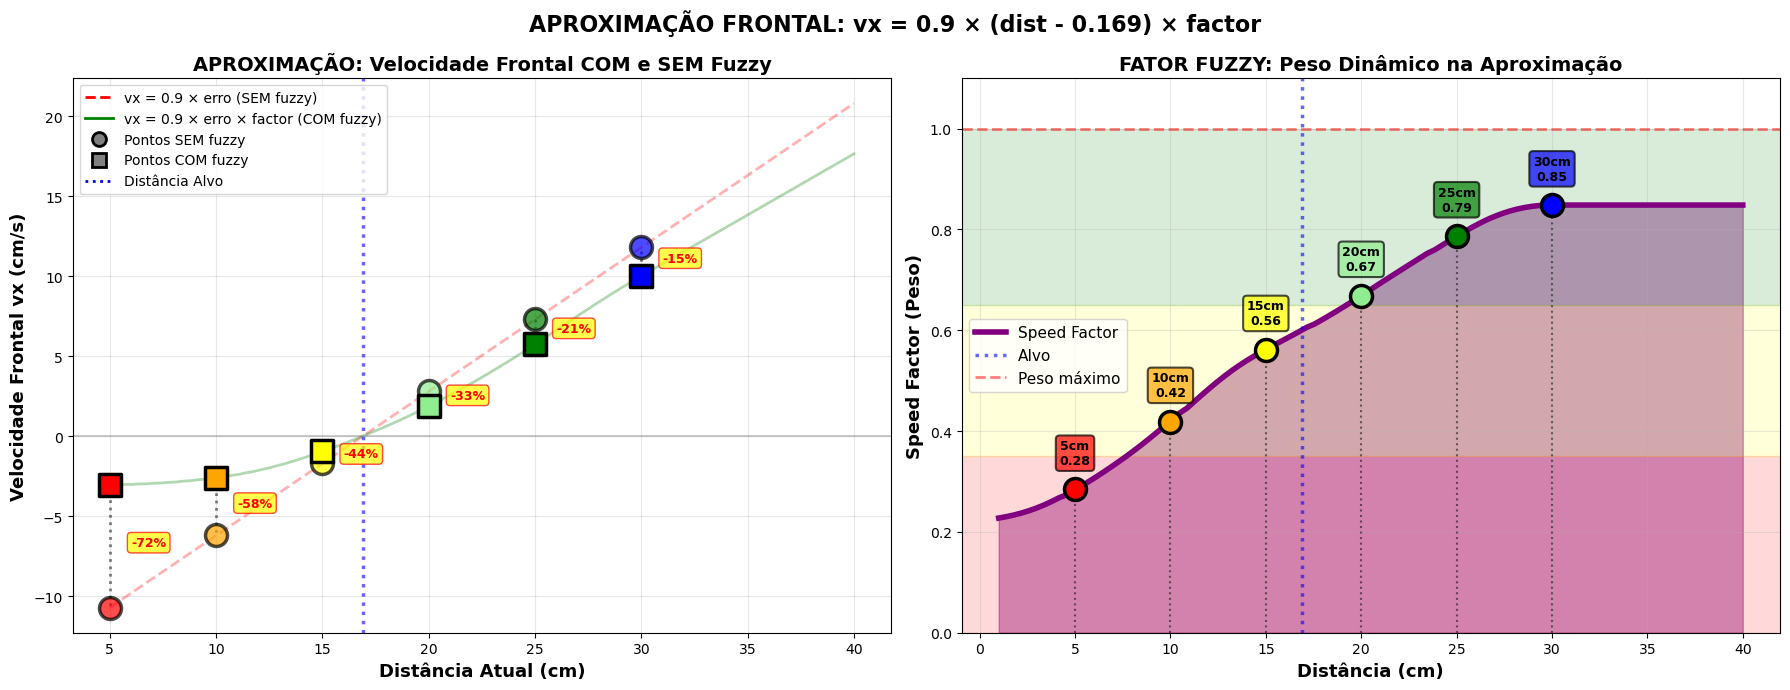


 APROXIMAÇÃO FRONTAL: vx = (0.9 × erro) × speed_factor
Distância Alvo: 16.9 cm

Distância    Erro         Factor     vx SEM       vx COM       Redução
----------------------------------------------------------------------
     5 cm     -11.9 cm     0.284    -10.71 cm/s    -3.04 cm/s    71.6%
    10 cm      -6.9 cm     0.419     -6.21 cm/s    -2.60 cm/s    58.1%
    15 cm      -1.9 cm     0.562     -1.71 cm/s    -0.96 cm/s    43.8%
    20 cm       3.1 cm     0.669      2.79 cm/s     1.87 cm/s    33.1%
    25 cm       8.1 cm     0.787      7.29 cm/s     5.74 cm/s    21.3%
    30 cm      13.1 cm     0.848     11.79 cm/s    10.00 cm/s    15.2%


In [73]:
# ========================================
# VISUALIZAÇÃO: APROXIMAÇÃO FRONTAL COM FUZZY (ESTILO LATERAL)
# ========================================

# Recriar estrutura fuzzy (mesmos parâmetros do youbot)
LIDAR_MAX = 0.3
V_MAX = 0.09
PICK_DISTANCE = 0.169

dist_array = np.arange(0, LIDAR_MAX + 0.001, 0.001)
near = fuzz.gaussmf(dist_array, 0.05, 0.04)
medium = fuzz.gaussmf(dist_array, 0.15, 0.05)
far = fuzz.gaussmf(dist_array, 0.25, 0.05)

v_array = np.arange(0, V_MAX + 0.001, 0.001)
v_low = fuzz.gaussmf(v_array, 0.20 * V_MAX, 0.10 * V_MAX)
v_med = fuzz.gaussmf(v_array, 0.55 * V_MAX, 0.12 * V_MAX)
v_high = fuzz.gaussmf(v_array, 0.90 * V_MAX, 0.10 * V_MAX)

def calcular_speed_factor(dist):
    idx = np.argmin(np.abs(dist_array - dist))
    μ_near = near[idx]
    μ_medium = medium[idx]
    μ_far = far[idx]
    
    rule1 = np.fmin(μ_near, v_low)
    rule2 = np.fmin(μ_medium, v_med)
    rule3 = np.fmin(μ_far, v_high)
    aggregated = np.fmax(rule1, np.fmax(rule2, rule3))
    
    v_fuzzy = fuzz.defuzz(v_array, aggregated, 'centroid')
    return v_fuzzy / V_MAX

# ===== VISUALIZAÇÃO =====
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ===== GRÁFICO 1: COMPARAÇÃO COM DESTAQUE EM PONTOS =====
ax1 = axes[0]

# Curva contínua de fundo
distances_cont = np.linspace(0.05, 0.40, 200)
vx_sem_cont = []
vx_com_cont = []

for dist in distances_cont:
    err = dist - PICK_DISTANCE
    vx_p = 0.9 * err
    factor = calcular_speed_factor(dist)
    
    vx_sem_cont.append(vx_p * 100)
    vx_com_cont.append(vx_p * factor * 100)

ax1.plot(distances_cont*100, vx_sem_cont, 'r--', linewidth=2, alpha=0.3, label='vx = 0.9 × erro')
ax1.plot(distances_cont*100, vx_com_cont, 'g-', linewidth=2, alpha=0.3, label='vx = 0.9 × erro × factor')

# Pontos destacados
distancias_teste = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
colors = ['red', 'orange', 'yellow', 'lightgreen', 'green', 'blue']

for dist, color in zip(distancias_teste, colors):
    err = dist - PICK_DISTANCE
    vx_sem = 0.9 * err * 100  # cm/s
    factor = calcular_speed_factor(dist)
    vx_com = vx_sem * factor
    
    # Pontos grandes
    ax1.scatter([dist*100], [vx_sem], s=250, c=color, marker='o', 
               edgecolor='black', linewidth=2.5, zorder=5, alpha=0.7)
    ax1.scatter([dist*100], [vx_com], s=250, c=color, marker='s', 
               edgecolor='black', linewidth=2.5, zorder=5)
    
    # Linha conectando os pontos
    ax1.plot([dist*100, dist*100], [vx_com, vx_sem], 'k:', linewidth=2, alpha=0.5)
    
    # Percentual de redução (CORRIGIDO: comparar magnitudes)
    if abs(vx_sem) > 0.1:  # Evita divisão por zero
        reducao = (abs(vx_sem) - abs(vx_com)) / abs(vx_sem) * 100
        mid_y = (vx_sem + vx_com) / 2
        ax1.text(dist*100 + 1, mid_y, f'-{reducao:.0f}%', 
                fontsize=9, fontweight='bold', color='red',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7, 
                        edgecolor='red', linewidth=1))

# Marca o alvo
ax1.axvline(PICK_DISTANCE*100, color='blue', linestyle=':', linewidth=2.5, alpha=0.6, label='Alvo (16.9cm)')
ax1.axhline(0, color='gray', linestyle='-', linewidth=1.5, alpha=0.4)

# Legenda customizada
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='r', linestyle='--', linewidth=2, label='vx = 0.9 × erro (SEM fuzzy)'),
    Line2D([0], [0], color='g', linestyle='-', linewidth=2, label='vx = 0.9 × erro × factor (COM fuzzy)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, 
           markeredgecolor='black', markeredgewidth=2, linestyle='', label='Pontos SEM fuzzy'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, 
           markeredgecolor='black', markeredgewidth=2, linestyle='', label='Pontos COM fuzzy'),
    Line2D([0], [0], color='blue', linestyle=':', linewidth=2, label='Distância Alvo')
]

ax1.set_xlabel('Distância Atual (cm)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Velocidade Frontal vx (cm/s)', fontsize=13, fontweight='bold')
ax1.set_title('APROXIMAÇÃO: Velocidade Frontal COM e SEM Fuzzy', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(handles=legend_elements, fontsize=10, loc='upper left')

# ===== GRÁFICO 2: SPEED FACTOR =====
ax2 = axes[1]
dists_plot = np.linspace(0.01, 0.40, 100)
factors = [calcular_speed_factor(d) for d in dists_plot]

ax2.plot(dists_plot*100, factors, 'purple', linewidth=4, label='Speed Factor')
ax2.fill_between(dists_plot*100, 0, factors, alpha=0.4, color='purple')

# Marcar pontos de teste
for dist, color in zip(distancias_teste, colors):
    factor = calcular_speed_factor(dist)
    ax2.scatter([dist*100], [factor], s=250, c=color, edgecolor='black', 
               linewidth=2.5, zorder=5)
    ax2.plot([dist*100, dist*100], [0, factor], 'k:', linewidth=1.5, alpha=0.5)
    ax2.text(dist*100, factor + 0.05, f'{dist*100:.0f}cm\n{factor:.2f}', 
            ha='center', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor=color, alpha=0.7, 
                     edgecolor='black', linewidth=1.5))

ax2.axvline(PICK_DISTANCE*100, color='blue', linestyle=':', linewidth=2.5, alpha=0.6, label='Alvo')
ax2.axhline(1.0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Peso máximo')

# Zonas
ax2.axhspan(0, 0.35, alpha=0.15, color='red')
ax2.axhspan(0.35, 0.65, alpha=0.15, color='yellow')
ax2.axhspan(0.65, 1.0, alpha=0.15, color='green')

ax2.set_xlabel('Distância (cm)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Speed Factor (Peso)', fontsize=13, fontweight='bold')
ax2.set_title('FATOR FUZZY: Peso Dinâmico na Aproximação', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)
ax2.set_ylim([0, 1.1])

plt.suptitle('APROXIMAÇÃO FRONTAL: vx = 0.9 × (dist - 0.169) × factor', 
            fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ===== RESUMO =====
print("\n" + "="*70)
print(" APROXIMAÇÃO FRONTAL: vx = (0.9 × erro) × speed_factor")
print("="*70)
print(f"Distância Alvo: {PICK_DISTANCE*100:.1f} cm\n")
print(f"{'Distância':<12} {'Erro':<12} {'Factor':<10} {'vx SEM':<12} {'vx COM':<12} {'Redução'}")
print("-"*70)

for dist in distancias_teste:
    err = dist - PICK_DISTANCE
    vx_sem = 0.9 * err * 100
    factor = calcular_speed_factor(dist)
    vx_com = vx_sem * factor
    reducao = ((abs(vx_sem) - abs(vx_com)) / abs(vx_sem) * 100) if abs(vx_sem) > 0.01 else 0
    
    print(f"{dist*100:>6.0f} cm    {err*100:>6.1f} cm    {factor:>6.3f}    "
          f"{vx_sem:>6.2f} cm/s   {vx_com:>6.2f} cm/s   {reducao:>5.1f}%")
print("="*70)

C:\Users\User\AppData\Local\Temp\ipykernel_36648\3261793679.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


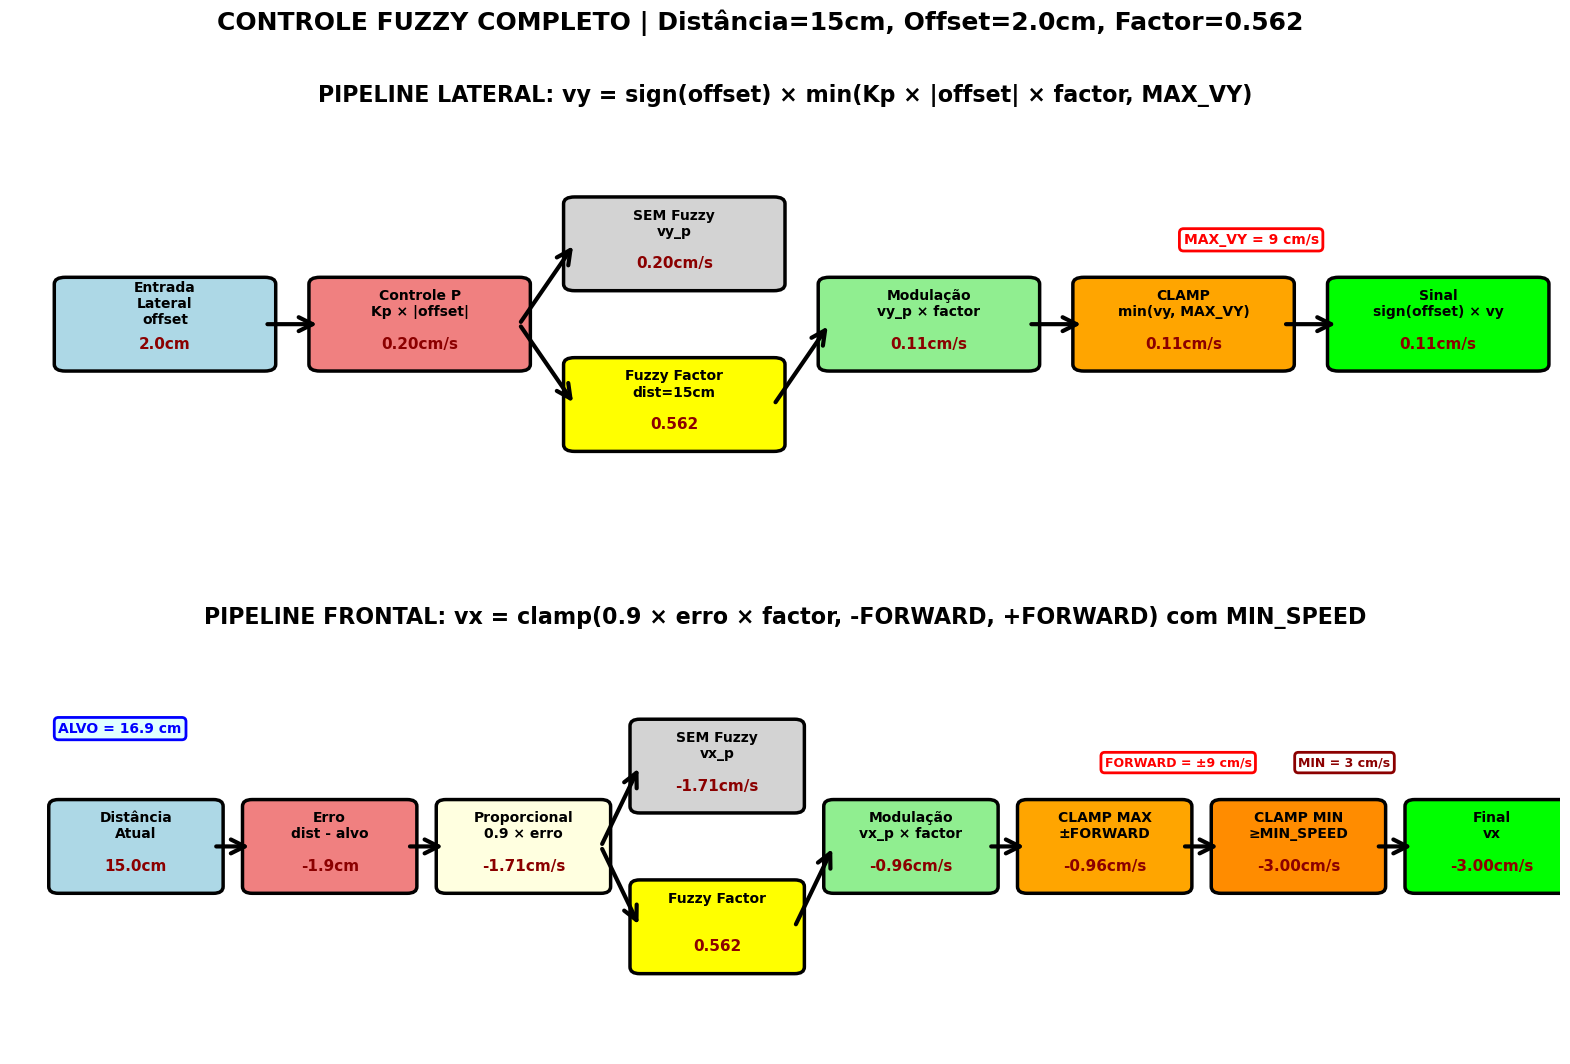

In [75]:
# ========================================
# PIPELINE COMPLETA: FUZZY MODULANDO VELOCIDADES COM CLAMP
# ========================================
# Este gráfico mostra o fluxo completo de como o fuzzy influencia
# as velocidades lateral (vy) e frontal (vx), incluindo os clamps

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
import numpy as np

# ===== PARÂMETROS REAIS DO ALIGNMENT_CONTROLLER =====
# (ajuste conforme seus valores reais)
KP = 0.1           # Ganho proporcional lateral
MAX_VY = 0.09      # Limite máximo vy
FORWARD_SPEED = 0.09  # Limite máximo |vx|
MIN_APPROACH_SPEED = 0.03  # Velocidade mínima de aproximação
PICK_DISTANCE = 0.169  # Distância alvo (m)
DEADZONE = 0.005   # Zona morta lateral

# ===== EXEMPLO CONCRETO =====
exemplo_dist = 0.15       # 15 cm do cubo
exemplo_lateral = 0.02    # 2 cm desalinhado
exemplo_erro = exemplo_dist - PICK_DISTANCE

# Calcula speed_factor
speed_factor = calcular_speed_factor(exemplo_dist)

# ===== PIPELINE LATERAL (vy) =====
vy_p = KP * abs(exemplo_lateral)
vy_fuzzy = vy_p * speed_factor
vy_clamped = min(vy_fuzzy, MAX_VY)
vy_final = np.sign(exemplo_lateral) * vy_clamped

# ===== PIPELINE FRONTAL (vx) =====
vx_p = 0.9 * exemplo_erro
vx_fuzzy = vx_p * speed_factor
vx_clamped = max(-FORWARD_SPEED, min(FORWARD_SPEED, vx_fuzzy))
# Clamp mínimo
if abs(vx_clamped) < MIN_APPROACH_SPEED:
    vx_final = np.sign(vx_clamped) * MIN_APPROACH_SPEED
else:
    vx_final = vx_clamped

# ===== VISUALIZAÇÃO =====
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 1, hspace=0.3)

# ========================================
# PIPELINE 1: VELOCIDADE LATERAL (vy)
# ========================================
ax1 = fig.add_subplot(gs[0])
ax1.set_xlim(0, 14)
ax1.set_ylim(0, 6)
ax1.axis('off')
ax1.set_title('PIPELINE LATERAL: vy = sign(offset) × min(Kp × |offset| × factor, MAX_VY)', 
              fontsize=16, fontweight='bold', pad=20)

# Boxes - Pipeline Lateral
lateral_boxes = [
    # (x, y, w, h, texto, cor, valor_display)
    (0.5, 2.5, 1.8, 1.2, f'Entrada\nLateral\noffset', 'lightblue', f'{exemplo_lateral*100:.1f}cm'),
    (2.8, 2.5, 1.8, 1.2, f'Controle P\nKp × |offset|', 'lightcoral', f'{vy_p*100:.2f}cm/s'),
    (5.1, 3.7, 1.8, 1.2, f'SEM Fuzzy\nvy_p', 'lightgray', f'{vy_p*100:.2f}cm/s'),
    (5.1, 1.3, 1.8, 1.2, f'Fuzzy Factor\ndist={exemplo_dist*100:.0f}cm', 'yellow', f'{speed_factor:.3f}'),
    (7.4, 2.5, 1.8, 1.2, f'Modulação\nvy_p × factor', 'lightgreen', f'{vy_fuzzy*100:.2f}cm/s'),
    (9.7, 2.5, 1.8, 1.2, f'CLAMP\nmin(vy, MAX_VY)', 'orange', f'{vy_clamped*100:.2f}cm/s'),
    (12.0, 2.5, 1.8, 1.2, f'Sinal\nsign(offset) × vy', 'lime', f'{vy_final*100:.2f}cm/s'),
]

for x, y, w, h, text, color, valor in lateral_boxes:
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1", 
                         facecolor=color, edgecolor='black', linewidth=2.5)
    ax1.add_patch(box)
    ax1.text(x + w/2, y + h/2 + 0.3, text, ha='center', va='center', 
            fontsize=10, fontweight='bold')
    ax1.text(x + w/2, y + h/2 - 0.3, valor, ha='center', va='center', 
            fontsize=11, fontweight='bold', color='darkred')

# Setas - Pipeline Lateral
lateral_arrows = [
    (2.3, 3.1, 2.8, 3.1),
    (4.6, 3.1, 5.1, 4.3),
    (4.6, 3.1, 5.1, 1.9),
    (6.9, 1.9, 7.4, 3.1),
    (9.2, 3.1, 9.7, 3.1),
    (11.5, 3.1, 12.0, 3.1),
]

for x1, y1, x2, y2 in lateral_arrows:
    arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->', 
                           mutation_scale=25, linewidth=3, color='black')
    ax1.add_patch(arrow)

# Anotações - MAX_VY
ax1.text(10.6, 4.3, f'MAX_VY = {MAX_VY*100:.0f} cm/s', 
        fontsize=10, color='red', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', linewidth=2))

# ========================================
# PIPELINE 2: VELOCIDADE FRONTAL (vx)
# ========================================
ax2 = fig.add_subplot(gs[1])
ax2.set_xlim(0, 16)
ax2.set_ylim(0, 6)
ax2.axis('off')
ax2.set_title('PIPELINE FRONTAL: vx = clamp(0.9 × erro × factor, -FORWARD, +FORWARD) com MIN_SPEED', 
              fontsize=16, fontweight='bold', pad=20)

# Boxes - Pipeline Frontal
frontal_boxes = [
    # (x, y, w, h, texto, cor, valor_display)
    (0.5, 2.5, 1.6, 1.2, f'Distância\nAtual', 'lightblue', f'{exemplo_dist*100:.1f}cm'),
    (2.5, 2.5, 1.6, 1.2, f'Erro\ndist - alvo', 'lightcoral', f'{exemplo_erro*100:.1f}cm'),
    (4.5, 2.5, 1.6, 1.2, f'Proporcional\n0.9 × erro', 'lightyellow', f'{vx_p*100:.2f}cm/s'),
    (6.5, 3.7, 1.6, 1.2, f'SEM Fuzzy\nvx_p', 'lightgray', f'{vx_p*100:.2f}cm/s'),
    (6.5, 1.3, 1.6, 1.2, f'Fuzzy Factor\n', 'yellow', f'{speed_factor:.3f}'),
    (8.5, 2.5, 1.6, 1.2, f'Modulação\nvx_p × factor', 'lightgreen', f'{vx_fuzzy*100:.2f}cm/s'),
    (10.5, 2.5, 1.6, 1.2, f'CLAMP MAX\n±FORWARD', 'orange', f'{vx_clamped*100:.2f}cm/s'),
    (12.5, 2.5, 1.6, 1.2, f'CLAMP MIN\n≥MIN_SPEED', 'darkorange', f'{vx_final*100:.2f}cm/s'),
    (14.5, 2.5, 1.6, 1.2, f'Final\nvx', 'lime', f'{vx_final*100:.2f}cm/s'),
]

for x, y, w, h, text, color, valor in frontal_boxes:
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1", 
                         facecolor=color, edgecolor='black', linewidth=2.5)
    ax2.add_patch(box)
    ax2.text(x + w/2, y + h/2 + 0.3, text, ha='center', va='center', 
            fontsize=10, fontweight='bold')
    ax2.text(x + w/2, y + h/2 - 0.3, valor, ha='center', va='center', 
            fontsize=11, fontweight='bold', color='darkred')

# Setas - Pipeline Frontal
frontal_arrows = [
    (2.1, 3.1, 2.5, 3.1),
    (4.1, 3.1, 4.5, 3.1),
    (6.1, 3.1, 6.5, 4.3),
    (6.1, 3.1, 6.5, 1.9),
    (8.1, 1.9, 8.5, 3.1),
    (10.1, 3.1, 10.5, 3.1),
    (12.1, 3.1, 12.5, 3.1),
    (14.1, 3.1, 14.5, 3.1),
]

for x1, y1, x2, y2 in frontal_arrows:
    arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->', 
                           mutation_scale=25, linewidth=3, color='black')
    ax2.add_patch(arrow)

# Anotações - Limites
ax2.text(11.3, 4.3, f'FORWARD = ±{FORWARD_SPEED*100:.0f} cm/s', 
        fontsize=9, color='red', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', linewidth=2))
ax2.text(13.3, 4.3, f'MIN = {MIN_APPROACH_SPEED*100:.0f} cm/s', 
        fontsize=9, color='darkred', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='darkred', linewidth=2))

# Anotação ALVO
ax2.text(0.5, 4.8, f'ALVO = {PICK_DISTANCE*100:.1f} cm', 
        fontsize=10, color='blue', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightcyan', edgecolor='blue', linewidth=2))

plt.suptitle(f'CONTROLE FUZZY COMPLETO | Distância={exemplo_dist*100:.0f}cm, Offset={exemplo_lateral*100:.1f}cm, Factor={speed_factor:.3f}', 
            fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
